In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('datasets/personality_dataset.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [3]:
df.shape

(2900, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [6]:
print(df.duplicated().sum())

388


In [7]:
df = df.drop_duplicates(keep='first')

In [8]:
df.isnull().sum()

Time_spent_Alone             61
Stage_fear                   73
Social_event_attendance      61
Going_outside                65
Drained_after_socializing    51
Friends_circle_size          75
Post_frequency               63
Personality                   0
dtype: int64

In [9]:
df[["Time_spent_Alone", "Social_event_attendance", "Going_outside", "Friends_circle_size", "Post_frequency"]] = df[["Time_spent_Alone", "Social_event_attendance", "Going_outside", "Friends_circle_size", "Post_frequency"]].apply(lambda x: x.fillna(x.median()))

In [10]:
df["Stage_fear"] = df["Stage_fear"].fillna(df["Stage_fear"].mode()[0])
df["Drained_after_socializing"] = df["Drained_after_socializing"].fillna(df["Drained_after_socializing"].mode()[0])

# **1. Data Vizualization**

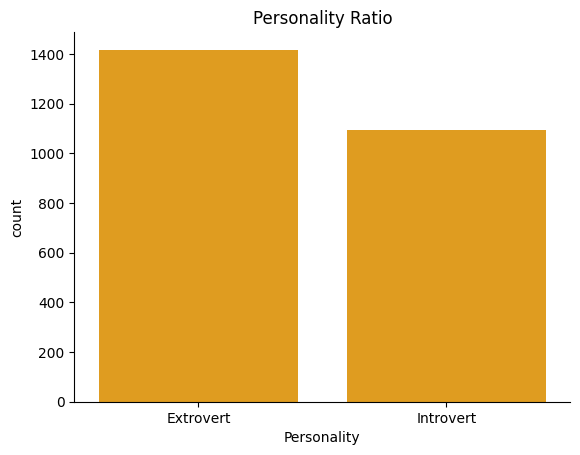

In [28]:
sns.countplot(data=df, x='Personality', color='orange')
plt.title('Personality Ratio')
sns.despine()
plt.show()

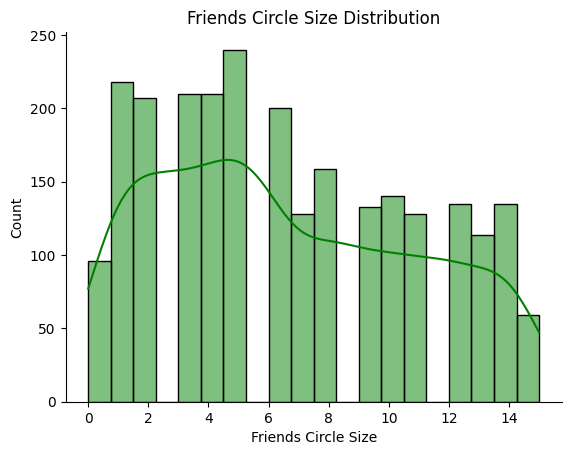

In [11]:
sns.histplot(data=df, x="Friends_circle_size", bins=20, kde=True, color='green')
plt.title('Friends Circle Size Distribution')
plt.xlabel('Friends Circle Size')
sns.despine()
plt.show()

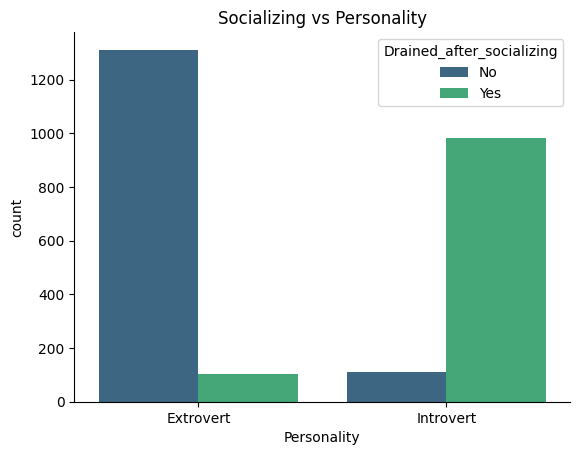

In [12]:
sns.countplot(data=df, hue='Drained_after_socializing', x='Personality', palette='viridis')
plt.title('Socializing vs Personality')
sns.despine()
plt.show()

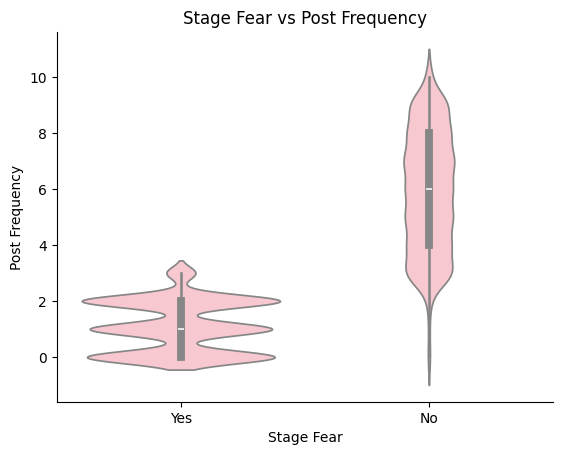

In [19]:
sns.violinplot(data=df, x='Stage_fear', y='Post_frequency', order=['Yes', 'No'], color='pink')
plt.xlabel('Stage Fear')
plt.ylabel('Post Frequency')
plt.title('Stage Fear vs Post Frequency')
sns.despine()
plt.show()

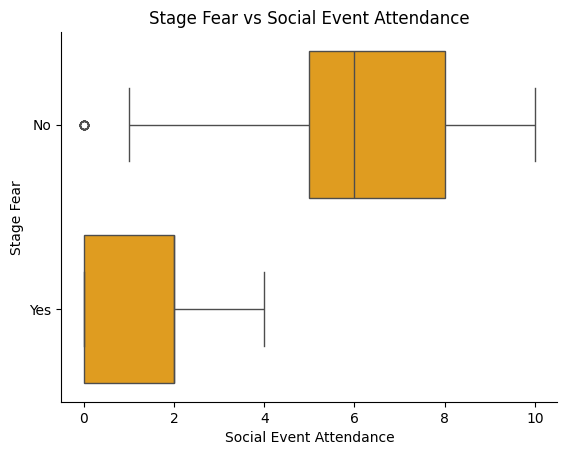

In [24]:
sns.boxplot(data=df, y='Stage_fear', x='Social_event_attendance', color='orange')
plt.title('Stage Fear vs Social Event Attendance')
plt.ylabel('Stage Fear')
plt.xlabel('Social Event Attendance')
sns.despine()
plt.show()

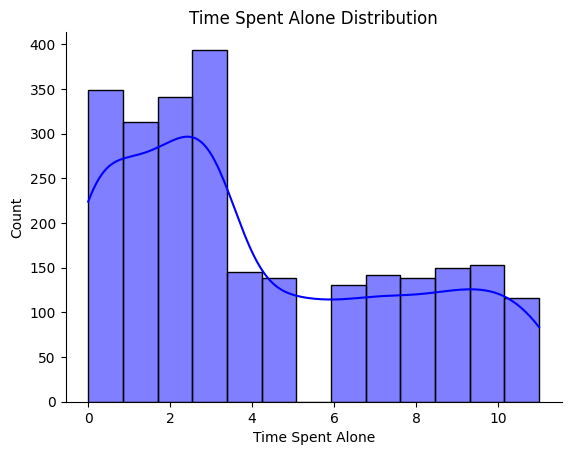

In [33]:
sns.histplot(data=df, x='Time_spent_Alone', color='blue', kde=True)
plt.title('Time Spent Alone Distribution')
plt.xlabel('Time Spent Alone')
sns.despine()
plt.show()

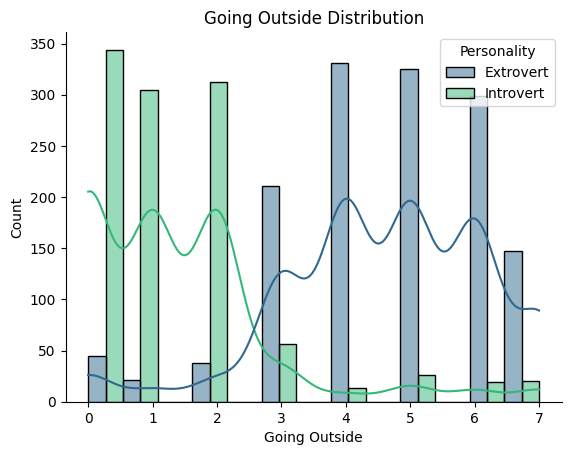

In [39]:
sns.histplot(data=df, x='Going_outside', hue='Personality', kde=True, multiple='dodge', palette='viridis')
plt.title('Going Outside Distribution')
plt.xlabel('Going Outside')
sns.despine()
plt.show()

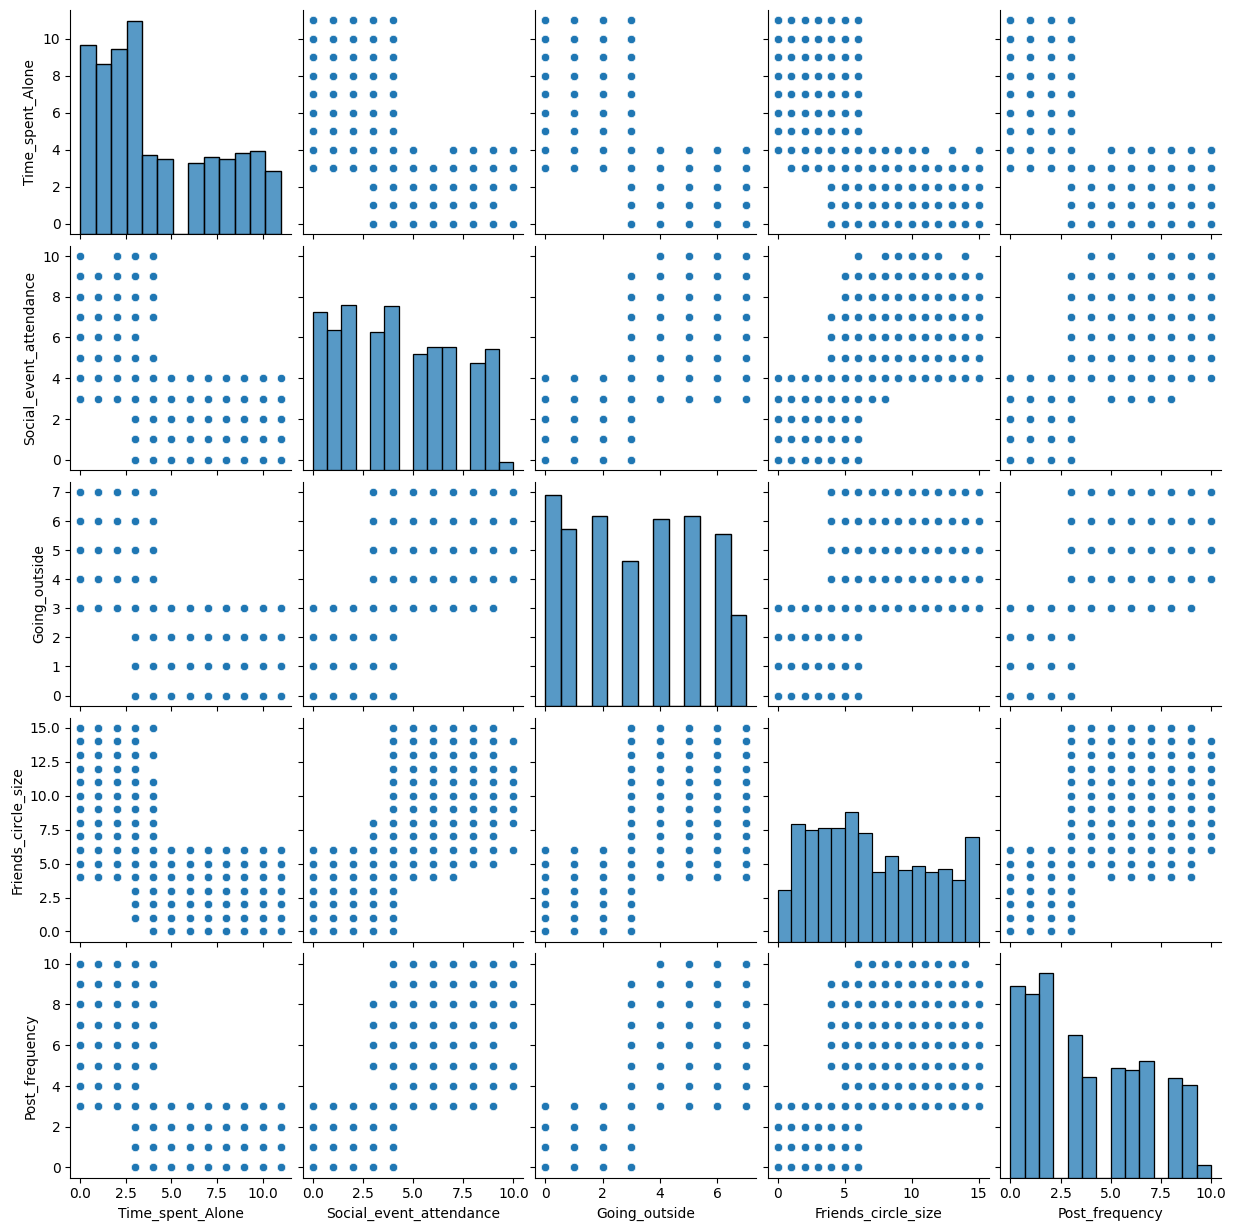

In [48]:
sns.pairplot(df)

<AxesSubplot: >

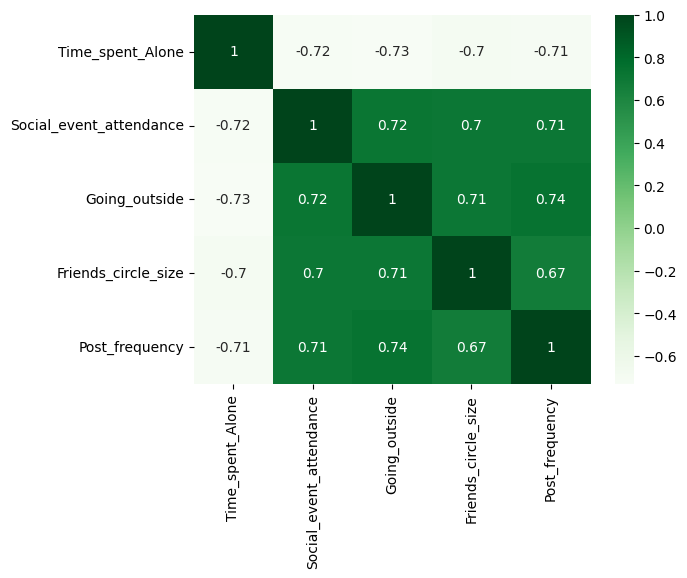

In [51]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')

# **2. Predictive Modelling**

In [42]:
df.head(2)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert


In [43]:
df.Time_spent_Alone.unique()

array([ 4.,  9.,  0.,  3.,  1.,  2., 10.,  6.,  5.,  8.,  7., 11.])

In [44]:
from sklearn.model_selection import train_test_split

num_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
cat_features = ['Stage_fear', 'Drained_after_socializing']

X = df[num_features + cat_features]
y = df['Personality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

prep = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(), cat_features)
])

## **1. Logistic Regression**

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = LogisticRegression(max_iter=1000, random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classfier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classfier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Accuracy: 0.92
AUC: 0.93
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.93      0.93      0.93       427
   Introvert       0.91      0.91      0.91       327

    accuracy                           0.92       754
   macro avg       0.92      0.92      0.92       754
weighted avg       0.92      0.92      0.92       754



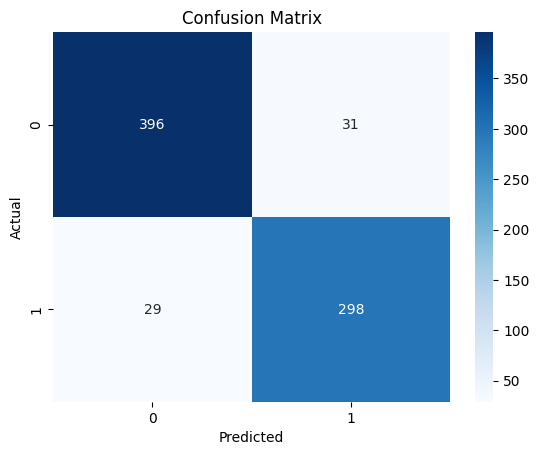

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **2. RandomForest**

In [88]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classfier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classfier', RandomForestClassifier(random_state=42))])

Accuracy: 0.91
AUC: 0.95
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.92      0.91      0.92       427
   Introvert       0.89      0.90      0.89       327

    accuracy                           0.91       754
   macro avg       0.90      0.90      0.90       754
weighted avg       0.91      0.91      0.91       754



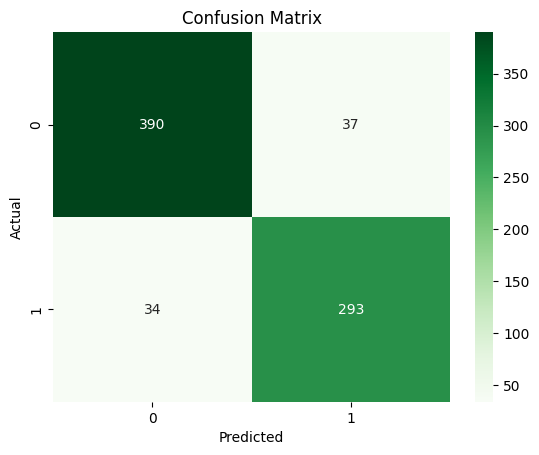

In [90]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **3. Support Vector Classifier**

In [94]:
from sklearn.svm import SVC

clf = SVC(probability=True, random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classfier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classfier', SVC(probability=True, random_state=42))])

Accuracy: 0.93
AUC: 0.95
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.95      0.93      0.94       427
   Introvert       0.91      0.93      0.92       327

    accuracy                           0.93       754
   macro avg       0.93      0.93      0.93       754
weighted avg       0.93      0.93      0.93       754



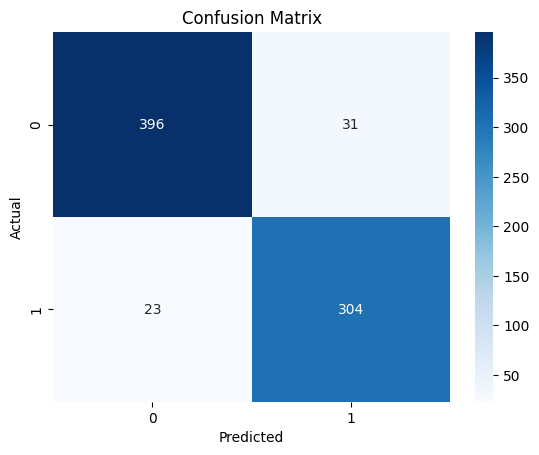

In [95]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **4. Naive Bayes**

In [96]:
from sklearn.naive_bayes import GaussianNB

clf = GaussianNB()
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classfier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classfier', GaussianNB())])

Accuracy: 0.93
AUC: 0.90
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.95      0.93      0.94       427
   Introvert       0.91      0.93      0.92       327

    accuracy                           0.93       754
   macro avg       0.93      0.93      0.93       754
weighted avg       0.93      0.93      0.93       754



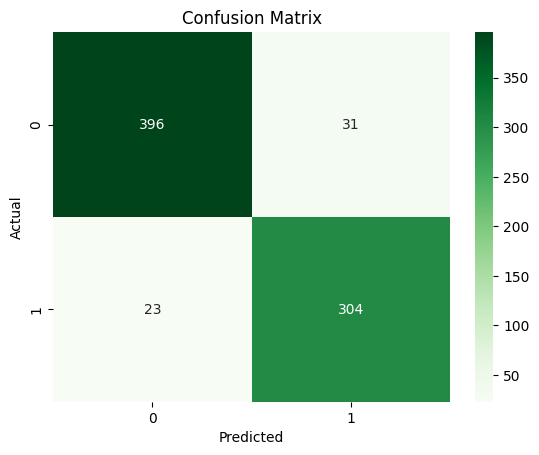

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **5. K-Nearest Neighbor**

In [98]:
max_k = np.sqrt(2500)
max_k

50.0

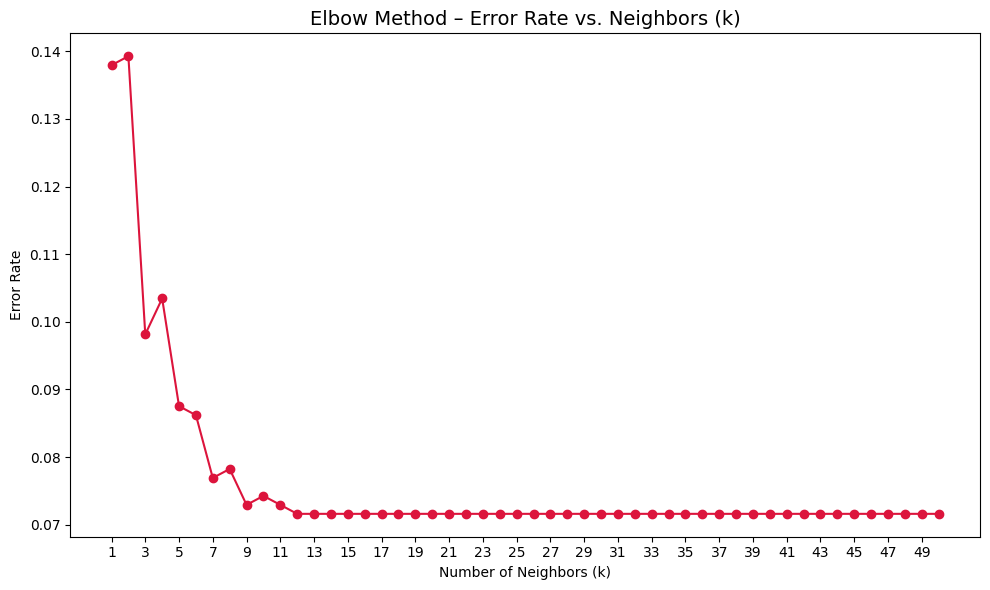

In [99]:
from sklearn.neighbors import KNeighborsClassifier

error_rates = []
k_range = range(1,51)

for k in k_range:
    model = Pipeline([
        ('preprocessor', prep),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rates, marker='o', linestyle='-', color='crimson')
plt.title('Elbow Method – Error Rate vs. Neighbors (k)', fontsize=14)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.xticks(k_range[::2])  # show every second k to make the plot clearer
plt.tight_layout()
plt.show()

In [100]:
clf = KNeighborsClassifier(n_neighbors=12)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classfier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classfier', KNeighborsClassifier(n_neighbors=12))])

Accuracy: 0.93
AUC: 0.96
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.95      0.93      0.94       427
   Introvert       0.91      0.93      0.92       327

    accuracy                           0.93       754
   macro avg       0.93      0.93      0.93       754
weighted avg       0.93      0.93      0.93       754



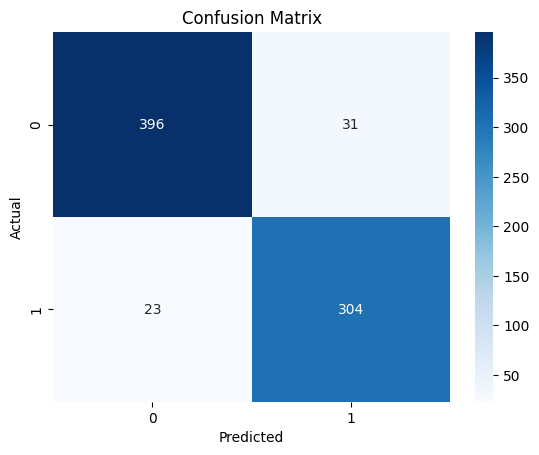

In [101]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **6. XGBoost**

In [102]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.fit_transform(y_test)

clf = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classifier', clf)
])
model.fit(X_train, y_train_encoded)

C:\Users\42060\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:15:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy: 0.90
AUC: 0.96
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       427
           1       0.89      0.90      0.89       327

    accuracy                           0.90       754
   macro avg       0.90      0.90      0.90       754
weighted avg       0.90      0.90      0.90       754



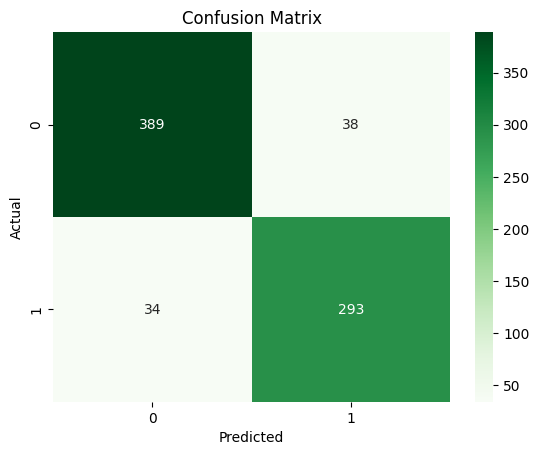

In [104]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test_encoded, y_pred)
cm = confusion_matrix(y_test_encoded, y_pred)
cr = classification_report(y_test_encoded, y_pred)
auc = roc_auc_score(y_test_encoded, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **7. GradientBoost**

In [105]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classifier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

Accuracy: 0.93
AUC: 0.97
Classification report:
               precision    recall  f1-score   support

   Extrovert       0.95      0.93      0.94       427
   Introvert       0.91      0.93      0.92       327

    accuracy                           0.93       754
   macro avg       0.93      0.93      0.93       754
weighted avg       0.93      0.93      0.93       754



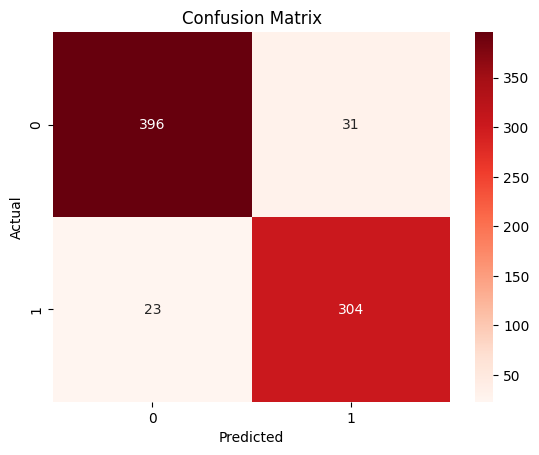

In [107]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.2f}')
print(f'AUC: {auc:.2f}')
print('Classification report:\n', cr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **3. Model Comparison**

C:\Users\42060\AppData\Local\Temp\ipykernel_1400\2406904560.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mod_df, x='Model', y='Accuracy', palette='viridis')


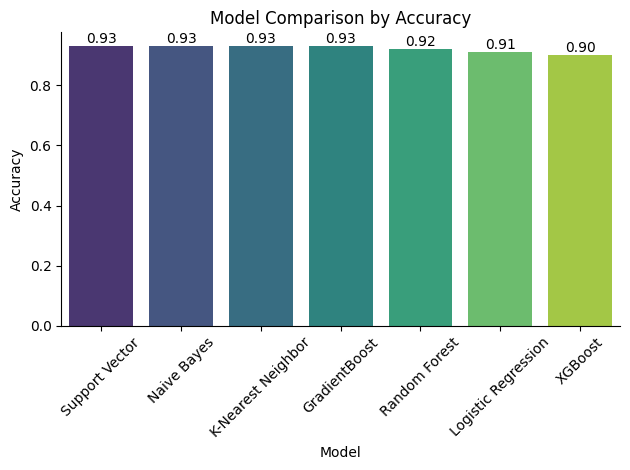

In [113]:
models = ['Logistic Regression', 'Random Forest', 'Support Vector', 'Naive Bayes', 'K-Nearest Neighbor', 'XGBoost', 'GradientBoost']
accuracy = [0.91, 0.92, 0.93, 0.93, 0.93, 0.90, 0.93]
mod_df = pd.DataFrame({'Model': models, 'Accuracy': accuracy}).sort_values(by='Accuracy', ascending=False)

ax = sns.barplot(data=mod_df, x='Model', y='Accuracy', palette='viridis')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
plt.title('Model Comparison by Accuracy')
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_1400\600112899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mod_df, x='Model', y='AUC', palette='viridis')


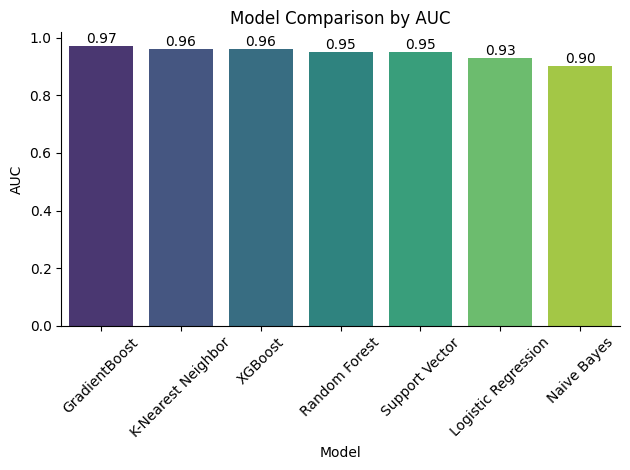

In [115]:
models = ['Logistic Regression', 'Random Forest', 'Support Vector', 'Naive Bayes', 'K-Nearest Neighbor', 'XGBoost', 'GradientBoost']
auc = [0.93, 0.95, 0.95, 0.90, 0.96, 0.96, 0.97]
mod_df = pd.DataFrame({'Model': models, 'AUC': auc}).sort_values(by='AUC', ascending=False)

ax = sns.barplot(data=mod_df, x='Model', y='AUC', palette='viridis')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
plt.title('Model Comparison by AUC')
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_1400\1813260273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mod_df, x='Model', y='F1 Score', palette='viridis')


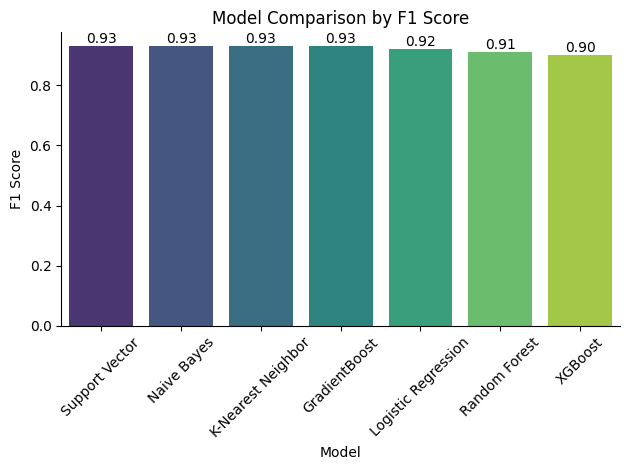

In [116]:
models = ['Logistic Regression', 'Random Forest', 'Support Vector', 'Naive Bayes', 'K-Nearest Neighbor', 'XGBoost', 'GradientBoost']
f1 = [0.92, 0.91, 0.93, 0.93, 0.93, 0.90, 0.93]
mod_df = pd.DataFrame({'Model': models, 'F1 Score': f1}).sort_values(by='F1 Score', ascending=False)

ax = sns.barplot(data=mod_df, x='Model', y='F1 Score', palette='viridis')
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
plt.title('Model Comparison by F1 Score')
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I choose GradientBoost.

In [118]:
clf = GradientBoostingClassifier(random_state=42)
model = Pipeline(steps=[
    ('preprocessor', prep),
    ('classifier', clf)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

C:\Users\42060\AppData\Local\Temp\ipykernel_1400\569583806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, y='Feature', x='Importance', palette='Spectral')


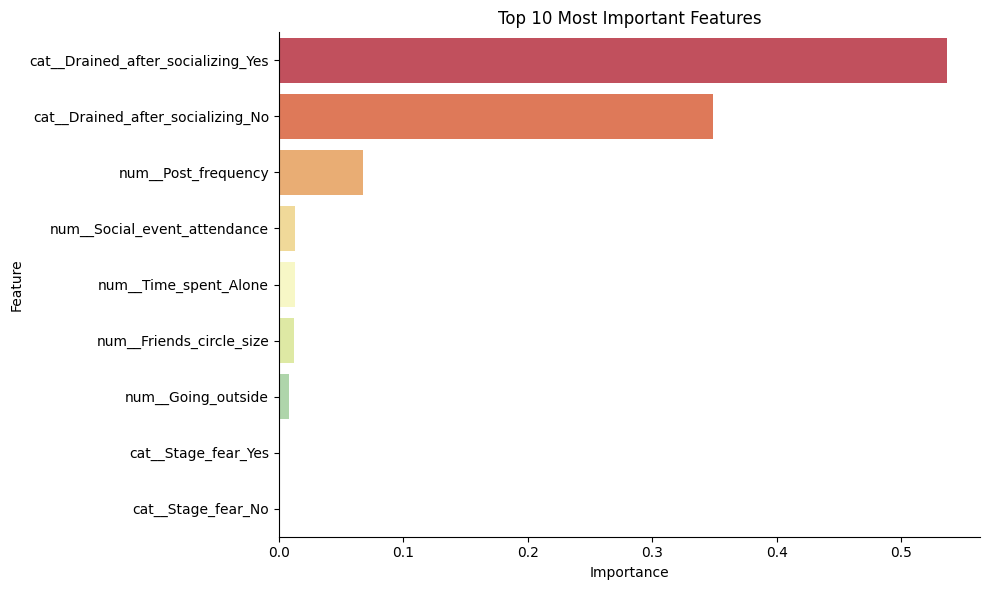

In [122]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['classifier'].feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, y='Feature', x='Importance', palette='Spectral')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
sns.despine()
plt.show()